## K-means clustering and Hierarchical Clustering

* Customer Segmentation

## 1 Import Libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Import Library for Kmeans Clustering
from sklearn.cluster import KMeans
# Import Library for Cluster Performance Metrics
from sklearn.metrics import silhouette_score

import warnings
warnings.filterwarnings('ignore')


## 2. Read Dataset

In [12]:
mall_customers = pd.read_csv('https://raw.githubusercontent.com/ammishra08/Machine-Learning/refs/heads/master/Datasets/Mall_Customers.csv')
mall_customers.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
mall_customers.shape

(200, 5)

In [5]:
mall_customers.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [6]:
mall_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
mall_customers.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## 3. EDA - show the bar graph 

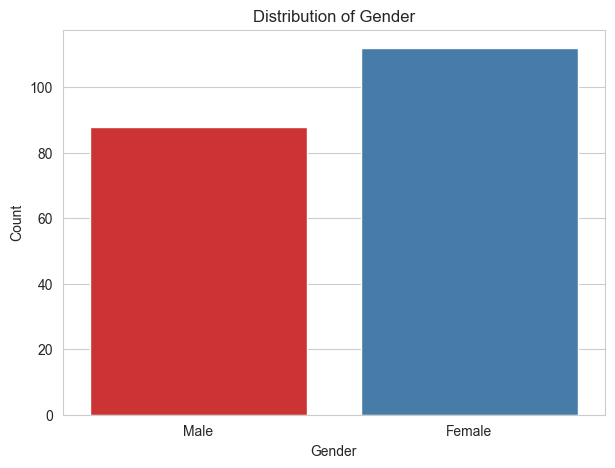

In [ ]:
# Plot bar graph showing distribution of Gender
 
sns.set_style('whitegrid')

plt.figure(figsize=(7, 5))
sns.countplot(data=mall_customers, x='Gender', palette='Set1') # we have 3 options 1)cat.plot, 2) bar.plot, 3.)count.plot
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

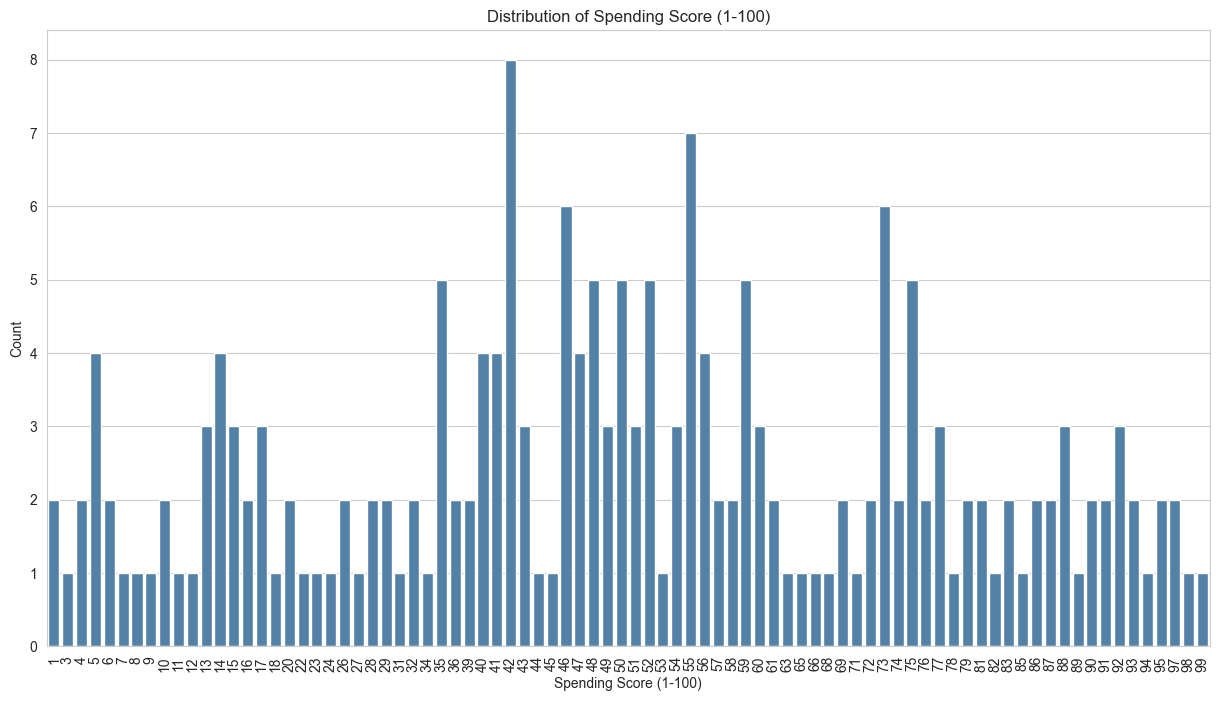

In [16]:
# Plot bar graph showing distribution of Spending Score (1-100)
plt.figure(figsize=(15, 8))
sns.countplot(data=mall_customers, x='Spending Score (1-100)', color='steelblue')
plt.title('Distribution of Spending Score (1-100)')
plt.xlabel('Spending Score (1-100)')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

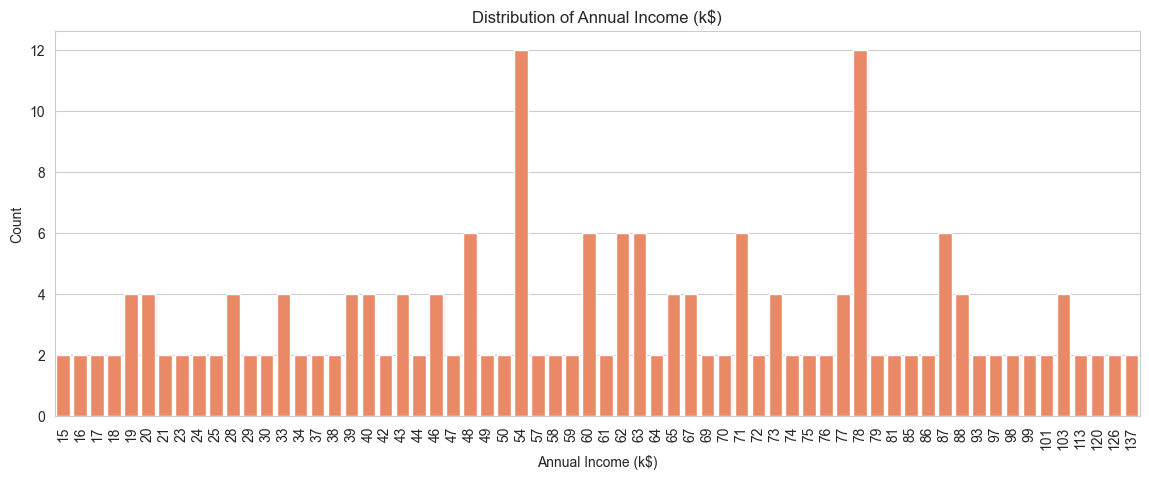

In [ ]:
# Plot bar graph showing distribution of Annual Income (k$)
plt.figure(figsize=(14, 5))
sns.countplot(data=mall_customers, x='Annual Income (k$)', color='coral')
plt.title('Distribution of Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()

## 4. Features

In [24]:
X = mall_customers.iloc[:, [3,4]]

In [25]:
X

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


## 5.Elbow Method

In [26]:
wcss = []
for i in range(1, 15):
    # init = method for intialization (k-means++) of cluster centers for k-means clustering
    # n_clusters = number of clusters (k)
    # n_init = number of times k-means algorithm will run with random initial centroid values
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 2)
    kmeans.fit(X)
    # wcss = intertia_ = sum of squared distances of samples from their closest centroidal values
    wcss.append(kmeans.inertia_)

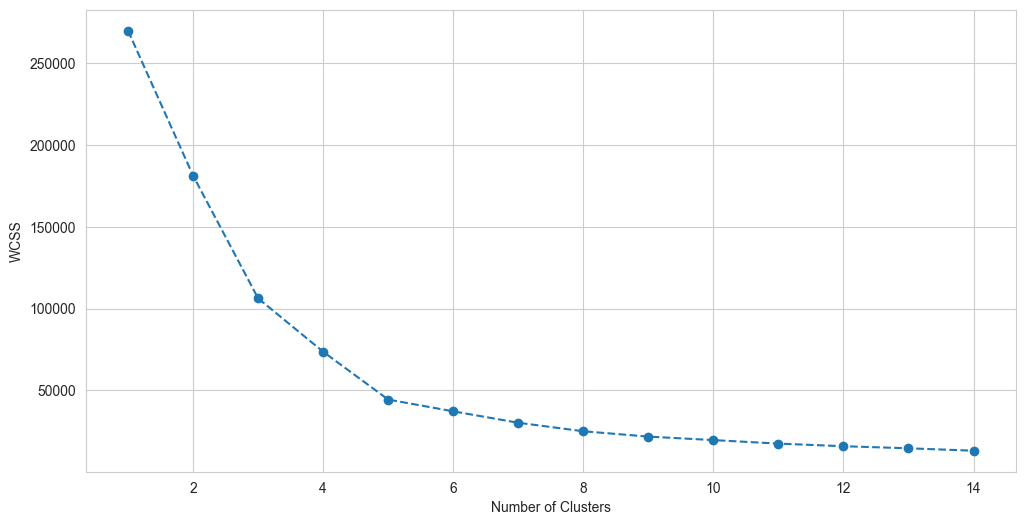

In [27]:
# Plot Graph between WCSS & Number of Clusters
plt.figure(figsize = (12, 6))
plt.plot(range(1, 15), wcss, marker = 'o', linestyle = '--')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [28]:
!pip install kneed


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
from kneed import KneeLocator
knee = KneeLocator(range(1, 15), wcss, curve = 'convex', direction = 'decreasing')
print(knee.elbow)

5


## 6. Train KMeans Clustering

In [30]:
kmeans = KMeans(n_clusters=5, init = 'k-means++', n_init = 10, max_iter = 300, random_state = 2)
kmeans.fit(X)

KMeans(n_clusters=5, n_init=10, random_state=2)

In [31]:
y_clusters = kmeans.predict(X)

In [32]:
print(y_clusters)

[2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2
 4 2 4 2 4 2 0 2 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 3 1 3 0 3 1 3 1 3 0 3 1 3 1 3 1 3 1 3 0 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3]


In [33]:
# cluster centrodal values
print(kmeans.cluster_centers_)

[[55.2962963  49.51851852]
 [88.2        17.11428571]
 [26.30434783 20.91304348]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]]


## Plot the Cluster & Centroids

In [34]:
X['Cluster'] = y_clusters

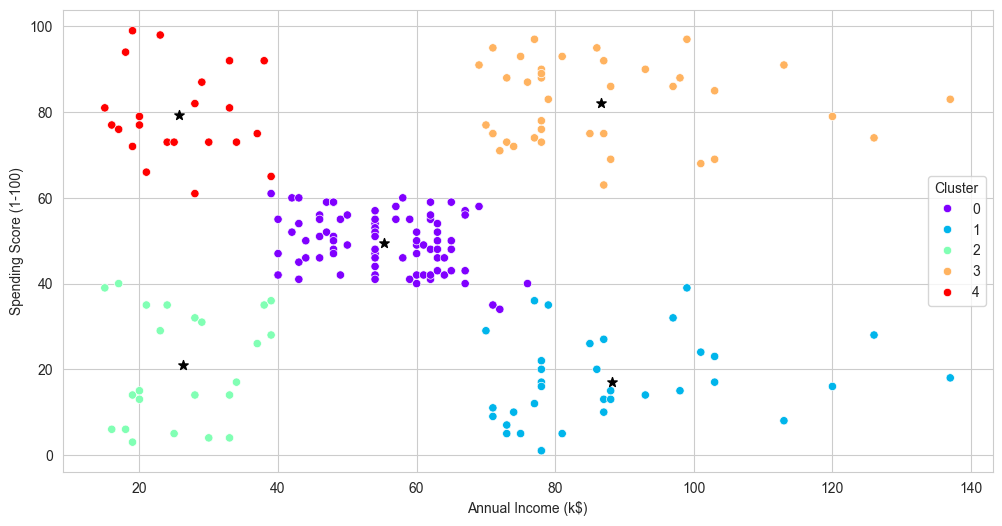

In [36]:
plt.figure(figsize = (12, 6))
sns.scatterplot(x = 'Annual Income (k$)', y = 'Spending Score (1-100)', hue = 'Cluster',
                data = X, palette = 'rainbow')
plt.scatter(x = kmeans.cluster_centers_[:, 0], y = kmeans.cluster_centers_[:, 1],
            c = 'black', marker = '*', s = 50, label = 'Centroids')
plt.show()

## 8. Clustering Score - Silhouette Score

In [37]:
from sklearn.metrics import silhouette_score
score = silhouette_score(X, y_clusters)
print(score)

0.5552901983515259


* 0.7 - 1.0 : Excellent Clustering

* 0.5 - 0.7 : Good

* 0.25 - 0.5 : Weak

* < 0.25 : Bad Clustering

## 8. Hierachical Clustering
*   Agglomerative Clustering
*   Divisive Clustering

In [38]:
from seaborn.matrix import dendrogram
import scipy.cluster.hierarchy as sch

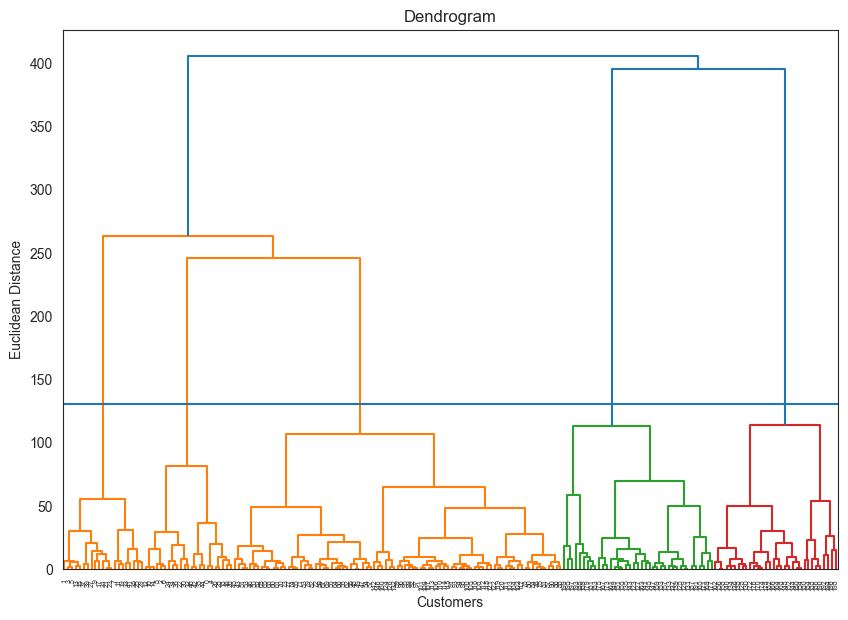

In [39]:
sns.set_style('white')
plt.figure(figsize = (10,7))
sch.dendrogram(sch.linkage(X, method = 'ward'))
plt.axhline(y = 130)
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

In [40]:
from sklearn.cluster import AgglomerativeClustering
# linkage = 'single' ; 'complete, average, 'ward'
hc = AgglomerativeClustering(n_clusters = 5, metric = 'euclidean', linkage = 'ward')
y_hc = hc.fit_predict(X)

In [42]:
X = mall_customers.iloc[:, [3,4]]
X ['Cluster'] = y_hc

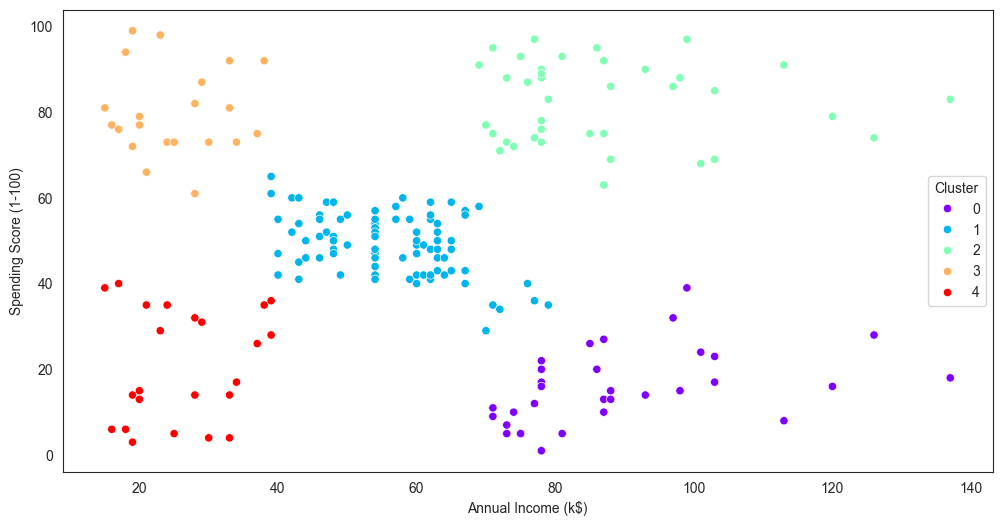

In [43]:
plt.figure(figsize = (12, 6))
sns.scatterplot(x = 'Annual Income (k$)', y = 'Spending Score (1-100)', hue = 'Cluster',
                data = X, palette = 'rainbow')
plt.show()